Student: Jefferson Gramal

# Face vs. Background Image Classification with VGG16

Train a binary image classifier with VGG16 transfer learning that recognizes **my face** and
separates it from any other image, which is labeled as **background**.

- `1` → `Jefferson`
- `0` → `Background`

VGG16 uses stacked $3 \times 3$ convolutional layers. Its pretrained feature extractor is frozen
while a small classification head is trained.

Since I only have a small number of photos of myself, the training set is **oversampled with
data augmentation**: rotations, flips, zoom, brightness and contrast changes, blur, noise,
grayscale and sharpening filters generate new versions of each photo.

## Individual graded activity

Build and test an image classifier that distinguishes a chosen student's face from background images.

- **Label 1:** student name
- **Label 2:** background (any image without that student's face)

### Tests

1. An unseen photo of the student. Expected label: student name. **(2 points)**
2. An unseen background image. Expected label: background. **(2 points)**
3. An unseen face of a different person. Expected label: background. **(6 points)**

### Optional hyperparameter experiments

Test dataset augmentation, loss function, optimizer, number of epochs, or batch size.

### Presentation

Present the results in class. The grade depends on success in all three tests.

## Dataset structure

Organize the images in two folders, one per class:

```
dataset/
├── Jefferson/     photos of my face: different days, lighting, angles, glasses, backgrounds
└── Background/    anything that is not me
```

Tips for the `Background` folder:

- **Include many faces of other people.** Test 3 is worth 6 points, so the model must learn that
  "a face" is not enough to be `Jefferson`. Around half of the background images should be faces
  of other people, the rest can be places, objects, animals, etc.
- Keep the photos used in the three tests **out of these folders**. Put them in a separate
  `test_images/` folder so they are truly unseen.

## 1. Install and import dependencies

In [1]:
!pip uninstall -y opencv-python opencv-python-headless
!pip install opencv-contrib-python-headless


Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 11.5 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


In [26]:
!unzip /content/Dataset.zip

Archive:  /content/Dataset.zip
replace Dataset/Jefferson/1.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Dataset/Jefferson/1.jpeg  
replace Dataset/Jefferson/2.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Dataset/Jefferson/2.jpeg  
replace Dataset/Jefferson/3.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Dataset/Jefferson/3.jpeg  
replace Dataset/Jefferson/4.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Dataset/Jefferson/4.jpeg  
replace Dataset/Jefferson/5.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace Dataset/Jefferson/5.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: Dataset/Jefferson/5.jpeg  
  inflating: Dataset/Jefferson/7.jpeg  
  inflating: Dataset/Jefferson/a.jpg  
  inflating: Dataset/Jefferson/a2.jpg  
  inflating: Dataset/Jefferson/b2.jpg  
  inflating: Dataset/Jefferson/d2.jpg  
  inflating: Dataset/Jefferson/fotografia.jpg  
  inflating: Dataset/Jefferson/I.jpg  
  inflatin

## 2. Configuration

`USE_FACE_CROP` detects the largest face in each image with OpenCV's Haar cascade and crops it
before resizing. This way the model focuses on the face instead of the room or the clothes, which
helps a lot to tell my face apart from other people's faces. If no face is found, the full image
is used, which is what happens with most background images.

In [27]:
DATASET_DIR = "/content/Dataset"
STUDENT_NAME = 'Jefferson'
BACKGROUND_NAME = 'Otros'

# Index 0 -> Background, index 1 -> student
CLASS_NAMES = [BACKGROUND_NAME, STUDENT_NAME]

IMG_SIZE = 224
USE_FACE_CROP = True
SEED = 42

np.random.seed(SEED)

## 3. Load the images

In [28]:
face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')


def crop_face(img_bgr, margin=0.25):
    # Crop the largest detected face with some margin; return the full image if there is no face
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
    if len(faces) == 0:
        return img_bgr

    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    mx, my = int(w * margin), int(h * margin)
    x0, y0 = max(x - mx, 0), max(y - my, 0)
    x1, y1 = min(x + w + mx, img_bgr.shape[1]), min(y + h + my, img_bgr.shape[0])
    return img_bgr[y0:y1, x0:x1]


def prepare_image(img_bgr):
    # Same steps for training images and for new images: downscale, crop face, resize, BGR -> RGB
    h, w = img_bgr.shape[:2]
    if max(h, w) > 1024:
        scale = 1024 / max(h, w)
        img_bgr = cv2.resize(img_bgr, (int(w * scale), int(h * scale)))

    if USE_FACE_CROP:
        img_bgr = crop_face(img_bgr)

    img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def load_images(folder, label):
    images = []
    labels = []

    for filename in sorted(os.listdir(folder)):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            images.append(prepare_image(img))
            labels.append(label)

    return images, labels


# Load images and labels from both classes
student_images, student_labels = load_images(os.path.join(DATASET_DIR, STUDENT_NAME), 1)
background_images, background_labels = load_images(os.path.join(DATASET_DIR, BACKGROUND_NAME), 0)

images = np.array(student_images + background_images)
labels = np.array(student_labels + background_labels)

print(f'{STUDENT_NAME} images: {len(student_images)}')
print(f'{BACKGROUND_NAME} images: {len(background_images)}')
print('Images shape:', images.shape)

Jefferson images: 29
Otros images: 33
Images shape: (62, 224, 224, 3)


## 4. Split the data into training, validation and test sets

The split is done **before** augmentation, using only the original photos. If the augmented
copies were created first, a rotated version of a photo could end up in training while the
original is in test, and the test accuracy would look better than it really is.

`stratify` keeps the same proportion of both classes in every set.

In [29]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=SEED
)

for name, y_set in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f'{name}: {len(y_set)} images -> {STUDENT_NAME}: {np.sum(y_set == 1)}, {BACKGROUND_NAME}: {np.sum(y_set == 0)}')

Train: 39 images -> Jefferson: 18, Otros: 21
Validation: 10 images -> Jefferson: 5, Otros: 5
Test: 13 images -> Jefferson: 6, Otros: 7


## 5. Data augmentation and oversampling

Each new image is created from an original training photo by combining random transformations:

- **Geometric:** horizontal flip, rotation of up to ±25°, random zoom and shift.
- **Filters:** brightness and contrast, Gaussian blur, Gaussian noise, grayscale, sharpening.

Both classes are oversampled up to `TARGET_PER_CLASS` images, so the training set ends up
balanced and much bigger. Only the **training set** is augmented; validation and test keep only
original photos.

In [30]:
rng = np.random.default_rng(SEED)


def random_rotation(img, max_angle=25):
    h, w = img.shape[:2]
    angle = rng.uniform(-max_angle, max_angle)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)


def horizontal_flip(img):
    return cv2.flip(img, 1)


def random_zoom(img, max_zoom=1.3):
    # Crop a random region and resize it back, which also shifts the image
    h, w = img.shape[:2]
    zoom = rng.uniform(1.0, max_zoom)
    new_h, new_w = int(h / zoom), int(w / zoom)
    y0 = rng.integers(0, h - new_h + 1)
    x0 = rng.integers(0, w - new_w + 1)
    return cv2.resize(img[y0:y0 + new_h, x0:x0 + new_w], (w, h))


def brightness_contrast(img):
    alpha = rng.uniform(0.7, 1.3)   # contrast
    beta = rng.uniform(-40, 40)     # brightness
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)


def gaussian_blur(img):
    k = int(rng.choice([3, 5]))
    return cv2.GaussianBlur(img, (k, k), 0)


def gaussian_noise(img):
    noise = rng.normal(0, rng.uniform(5, 15), img.shape)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)


def grayscale(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

#Sharpens the edges of the image to make it look crisper.
def sharpen(img):
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)


FILTERS = [brightness_contrast, gaussian_blur, gaussian_noise, grayscale, sharpen]


def augment_image(img):
    out = img.copy()

    # Geometric transformations
    if rng.random() < 0.5:
        out = horizontal_flip(out)
    if rng.random() < 0.7:
        out = random_rotation(out)
    if rng.random() < 0.5:
        out = random_zoom(out)

    # One or two random filters
    for idx in rng.choice(len(FILTERS), size=rng.integers(1, 3), replace=False):
        out = FILTERS[idx](out)

    return out


def oversample_class(class_images, target):
    # Keep the originals and add augmented copies until reaching the target
    result = list(class_images)
    i = 0
    while len(result) < target:
        result.append(augment_image(class_images[i % len(class_images)]))
        i += 1
    return result

In [31]:
# Both classes end up with the same number of training images
TARGET_PER_CLASS = max(500, np.sum(y_train == 0), np.sum(y_train == 1))

train_student = oversample_class(X_train[y_train == 1], TARGET_PER_CLASS)
train_background = oversample_class(X_train[y_train == 0], TARGET_PER_CLASS)

X_train_aug = np.array(train_student + train_background)
y_train_aug = np.array([1] * len(train_student) + [0] * len(train_background))

# Shuffle so the batches mix both classes
order = rng.permutation(len(X_train_aug))
X_train_aug, y_train_aug = X_train_aug[order], y_train_aug[order]

print(f'Training images before augmentation: {len(X_train)}')
print(f'Training images after augmentation: {len(X_train_aug)}')
print(f'{STUDENT_NAME}: {np.sum(y_train_aug == 1)}, {BACKGROUND_NAME}: {np.sum(y_train_aug == 0)}')

Training images before augmentation: 39
Training images after augmentation: 1000
Jefferson: 500, Otros: 500


## 6. Prepare the inputs for VGG16

`preprocess_input` applies the same normalization used when VGG16 was trained on ImageNet.
Labels are converted to one-hot vectors:

- `0` → `[1, 0]` (Background)
- `1` → `[0, 1]` (Jefferson)

In [32]:
X_train_in = preprocess_input(X_train_aug.astype('float32'))
X_val_in = preprocess_input(X_val.astype('float32'))
X_test_in = preprocess_input(X_test.astype('float32'))

y_train_cat = to_categorical(y_train_aug, num_classes=2)
y_val_cat = to_categorical(y_val, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# (# of pictures,224x224, RGB)(# of pictures, classes)
print(X_train_in.shape, y_train_cat.shape)

(1000, 224, 224, 3) (1000, 2)


## 7. Build and train the VGG16 classifier

In [35]:
# Stop when validation loss no longer improves and keep the best weights
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Load VGG16 without its original classifier
baseModel = VGG16(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Add a binary classification head
model = Sequential()
model.add(baseModel)
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.6))
model.add(Dense(2, activation='softmax'))

# Keep pretrained VGG16 weights fixed (freeze the convolutional base).
for layer in baseModel.layers:
    layer.trainable = False

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=['accuracy'])

history = model.fit(
    X_train_in, y_train_cat,
    validation_data=(X_val_in, y_val_cat),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 260ms/step - accuracy: 0.7450 - loss: 2.6732 - val_accuracy: 0.9000 - val_loss: 0.2025
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.9410 - loss: 0.2818 - val_accuracy: 0.9000 - val_loss: 0.2415
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.9660 - loss: 0.0884 - val_accuracy: 0.9000 - val_loss: 0.2377
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.9780 - loss: 0.0625 - val_accuracy: 0.9000 - val_loss: 0.1241
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.9810 - loss: 0.0699 - val_accuracy: 1.0000 - val_loss: 0.0090
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.9840 - loss: 0.0473 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.9870 - loss: 0.0455 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.9890 - loss: 0.0307 - val_accuracy: 1

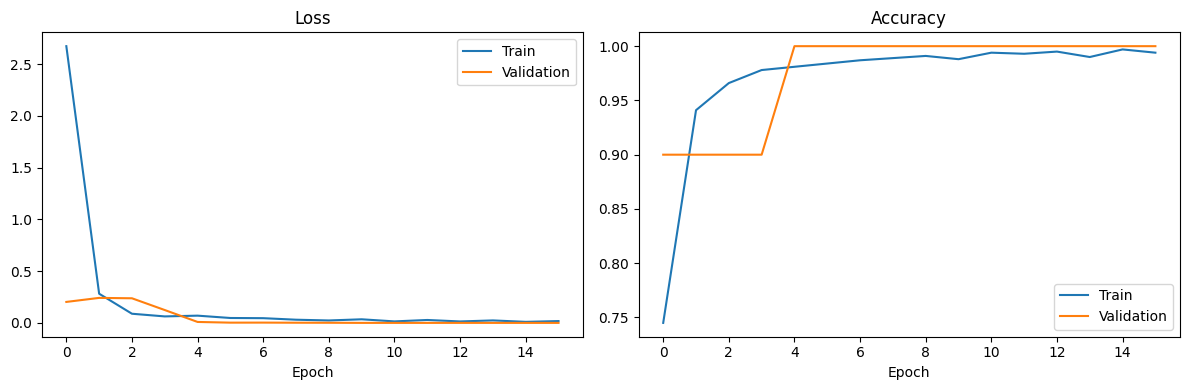

In [36]:
# Training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

## 8. Evaluate on the test set

The test set contains only original photos that the model never saw during training.

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.9231 - loss: 0.7248
Loss: 0.7247895002365112
Accuracy: 0.9230769276618958
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

       Otros       1.00      0.86      0.92         7
   Jefferson       0.86      1.00      0.92         6

    accuracy                           0.92        13
   macro avg       0.93      0.93      0.92        13
weighted avg       0.93      0.92      0.92        13



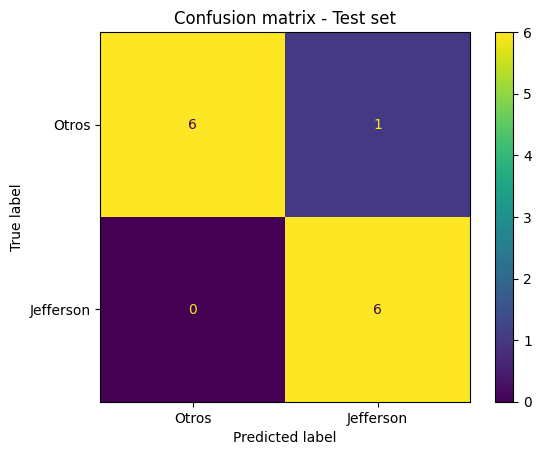

In [37]:
loss, accuracy = model.evaluate(X_test_in, y_test_cat)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

y_pred = np.argmax(model.predict(X_test_in), axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=CLASS_NAMES)
plt.title('Confusion matrix - Test set')
plt.show()

## Optional: Save and load the model

In [38]:
MODEL_PATH = f'{STUDENT_NAME.lower()}_vs_background_vgg16.keras'

# Save the model in Keras format
model.save(MODEL_PATH)

In [39]:
# Load the saved model
from keras.models import load_model
model = load_model(MODEL_PATH)

## 9. Predict new images

A new image goes through exactly the same steps as the training images: face crop, resize,
BGR → RGB and `preprocess_input`. Keras expects batches, even for one image, so `pred[0]`
contains the two class probabilities:

- `pred[0][0]`: Background
- `pred[0][1]`: Jefferson

In [40]:
def predict_image(path, expected=None):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(path)

    img = prepare_image(img_bgr)

    # Add a batch dimension: (1, 224, 224, 3)
    x = preprocess_input(np.expand_dims(img.astype('float32'), axis=0))
    pred = model.predict(x, verbose=0)
    print(pred)

    # Use the highest predicted probability as the class
    idx = int(np.argmax(pred[0]))
    label = CLASS_NAMES[idx]

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title('Original image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    title = f'Prediction: {label} ({pred[0][idx]:.1%})'
    if expected is not None:
        title += f'\nExpected: {expected} -> {"OK" if label == expected else "FAIL"}'
    plt.title(title)
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    return label

## 10. Graded tests

Put the three test photos in `test_images/` and adjust the file names if needed. None of these
photos should be inside the `dataset/` folder.

### Test 1: unseen photo of me (expected: Jefferson)

[[8.342662e-10 1.000000e+00]]


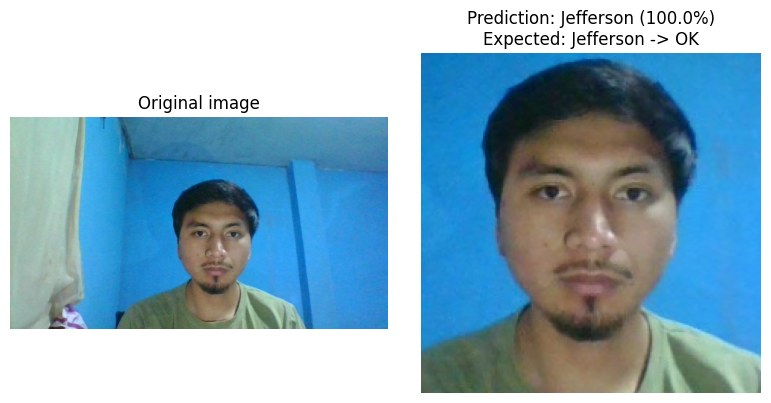

In [47]:
result_1 = predict_image('/content/WIN_20260924_22_16_04_Pro.jpg', expected=STUDENT_NAME)

### Test 2: unseen background image (expected: Background)

[[0.96475065 0.03524942]]


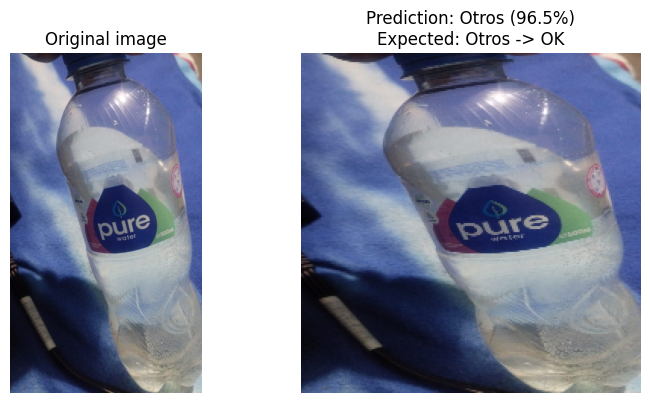

In [42]:
result_2 = predict_image('/content/5.jpeg', expected=BACKGROUND_NAME)

### Test 3: unseen face of a different person (expected: Background)

[[0.8948765  0.10512348]]


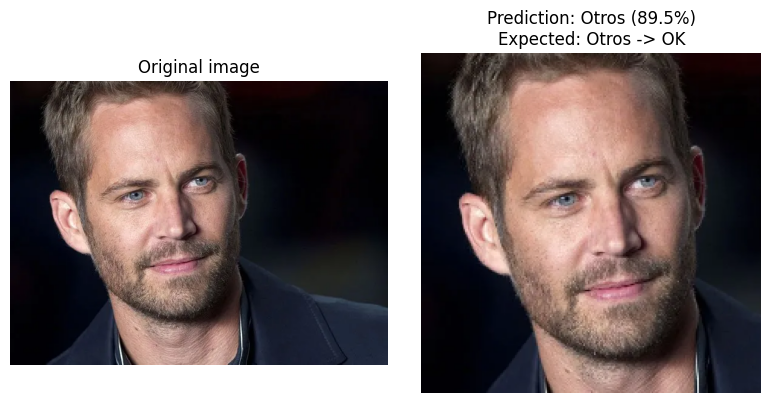

In [43]:
result_3 = predict_image('/content/0014139938jpg.webp', expected=BACKGROUND_NAME)

In [48]:
tests = [
    ('Test 1 - Unseen photo of me', result_1, STUDENT_NAME, 2),
    ('Test 2 - Unseen background image', result_2, BACKGROUND_NAME, 2),
    ('Test 3 - Unseen face of another person', result_3, BACKGROUND_NAME, 6),
]

score = 0
for name, result, expected, points in tests:
    passed = result == expected
    score += points if passed else 0
    print(f'{name}: predicted {result}, expected {expected} -> {"OK" if passed else "FAIL"}')

print(f'\nScore: {score}/10')

Test 1 - Unseen photo of me: predicted Jefferson, expected Jefferson -> OK
Test 2 - Unseen background image: predicted Otros, expected Otros -> OK
Test 3 - Unseen face of another person: predicted Otros, expected Otros -> OK

Score: 10/10


## Optional hyperparameter experiments

If a test fails, these are the easiest things to try:

- **Dataset augmentation:** change `TARGET_PER_CLASS`, or the ranges in `random_rotation`,
  `random_zoom` and `brightness_contrast`.
- **More faces in Background:** if test 3 fails, add more photos of other people's faces.
- **Optimizer:** try another learning rate, for example `Adam(learning_rate=1e-3)`, or `SGD`.
- **Epochs and batch size:** change `epochs`, `patience` or `batch_size` in the training cell.
- **Face crop:** compare the results with `USE_FACE_CROP = True` and `False`.